# Extracción de perfiles del International Multi-Tokamak Confinement Profile Database

In [1]:
import MDSplus
import numpy as np
import matplotlib.pyplot as plt

In [104]:
# Conexión a la base de Datos
conn = MDSplus.Connection('tokamak-profiledb.ccfe.ac.uk')
conn.openTree('pr08_rtp', 96040237)

In [105]:
amin = conn.get(r'\top.zerod:amin').data()
#rmag = conn.get(r'\top.zerod:rmag').data()
#zmag = conn.get(r'\top.zerod:zmag').data()
rgeo = conn.get(r'\top.zerod:rgeo').data()

In [106]:
# Obtención de los perfiles T y n como F(r,t)
Te = conn.get(r'\top.twod:te').data()
ne = conn.get(r'\top.twod:ne').data()

In [107]:
t = conn.get(r'dim_of(\top.twod:te,1)').data()
rho = conn.get(r'dim_of(\top.twod:te,0)').data() 

In [108]:
t

array([0.19])

In [91]:
Te_unit = conn.get(r'units_of(\top.twod:te)').data()
ne_unit = conn.get(r'units_of(\top.twod:ne)').data()
t_unit  = conn.get(r'units_of(dim_of(\top.twod:te,1))').data()
r_unit  = conn.get(r'units_of(dim_of(\top.twod:te,0))').data()

In [81]:
rho.max()

0.975

In [96]:
That = np.copy(Te / Te.max())
nhat = np.copy(ne / ne.max())

for tt in nhat:
    print(tt)

1.0
0.999550299051131
0.9983361064891847
0.9971443989746819
0.9819220218554661
0.9507802311462877
0.9199082610064307
0.8865854206952377
0.8555560552232765
0.8225030354814049
0.7874263614696227
0.7579484642712596
0.7304942213428071
0.7012861447137654
0.6675360885011468
0.625938750730764
0.5921212393758151
0.5636326842649638
0.5398210190223501
0.5251832531366641
0.5179430678598732
0.5041597337770383
0.4829563340378648
0.46820614291496154
0.44873409182893376
0.4327247380491973
0.4179070917839637
0.40628232225569993
0.38480910194720513
0.3620992040293205
0.34658452129333994
0.32936097495165717
0.3103611098619418
0.28960741107163734
0.26536852992759813
0.2411071637361155
0.2138215586634888
0.185557854027072
0.15693663713630435
0.1309012007015335


In [46]:
#assert Te.shape == (len(t), len(r)), f"Unexpected Te shape: {Te.shape}, t={len(t)}, r={len(r)}"
#assert ne.shape == (len(t), len(r)), f"Unexpected Te shape: {ne.shape}, t={len(t)}, r={len(r)}"

In [47]:
t0 = 9.6
itime = np.argmin(np.abs(t - t0))

In [48]:
#Te_r = Te[itime, :]
#ne_r = ne[itime, :]

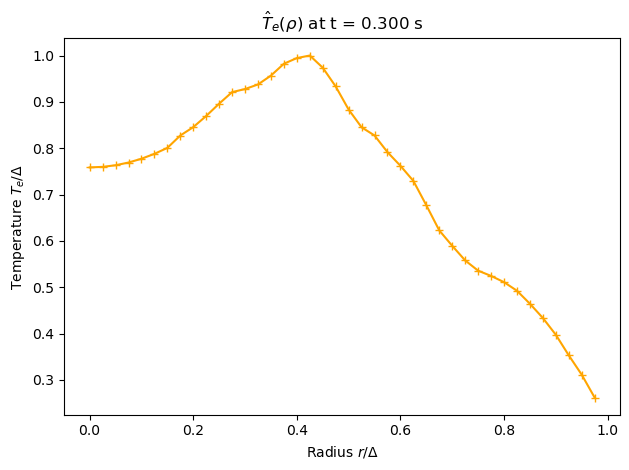

In [97]:
plt.figure()
plt.plot(rho, That, marker='+', linestyle='-', color='orange')
plt.xlabel(r"Radius $r / \Delta$")
plt.ylabel("Temperature $T_e / \Delta$")
plt.title(r"$\hat{T}_e(\rho)$ at t = " + f"{t[0]:.3f} {t_unit}")
plt.tight_layout()
plt.show()

NameError: name 'itime' is not defined

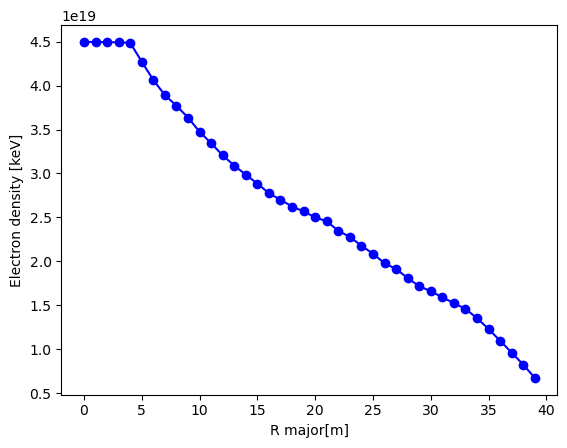

In [11]:
plt.figure()
plt.plot(ne, marker='o', linestyle='-', color='blue')
plt.xlabel(r"R major [m]")
plt.ylabel(f"Electron density [{ne_unit}]")
plt.title(rf"$n_e$(r) at t = {t[itime]:.3f} {t_unit}")
plt.grid(True)
plt.tight_layout()
plt.show()